In [1]:
"""
House Price Prediction using Linear Regression
Dataset: Boston Housing (506 samples, 13 features)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

## 1. LOAD & LABEL THE DATASET

In [2]:
COLUMNS = [
    "CRIM",    # per-capita crime rate by town
    "ZN",      # % residential land zoned for large lots
    "INDUS",   # % non-retail business acres per town
    "CHAS",    # Charles River dummy (1 if tract bounds river)
    "NOX",     # nitric oxide concentration (parts per 10M)
    "RM",      # avg number of rooms per dwelling
    "AGE",     # % owner-occupied units built before 1940
    "DIS",     # weighted distances to employment centres
    "RAD",     # index of accessibility to radial highways
    "TAX",     # full-value property-tax rate per $10,000
    "PTRATIO", # pupil-teacher ratio by town
    "B",       # 1000(Bk - 0.63)^2 where Bk = Black proportion
    "LSTAT",   # % lower-status population
    "PRICE",   # median home value in $1000s  ← TARGET
]

df = pd.read_csv(
    "/content/4) house Prediction Data Set.csv",
    header=None,
    names=COLUMNS,
    sep=r"\s+",   # whitespace-separated
    engine="python",
)

print("=" * 60)
print("         HOUSE PRICE PREDICTION — LINEAR REGRESSION")
print("=" * 60)

         HOUSE PRICE PREDICTION — LINEAR REGRESSION


## 2. EXPLORATORY DATA ANALYSIS

In [3]:
print("\n📊 Dataset Shape:", df.shape)
print("\n📋 First 5 Rows:")
print(df.head().to_string())
print("\n📈 Basic Statistics:")
print(df.describe().round(2).to_string())
print("\n🔍 Missing Values:", df.isnull().sum().sum(), "(none expected)")


📊 Dataset Shape: (506, 14)

📋 First 5 Rows:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  PTRATIO       B  LSTAT  PRICE
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0     15.3  396.90   4.98   24.0
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0     17.8  396.90   9.14   21.6
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0     17.8  392.83   4.03   34.7
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0     18.7  394.63   2.94   33.4
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0     18.7  396.90   5.33   36.2

📈 Basic Statistics:
         CRIM      ZN   INDUS    CHAS     NOX      RM     AGE     DIS     RAD     TAX  PTRATIO       B   LSTAT   PRICE
count  506.00  506.00  506.00  506.00  506.00  506.00  506.00  506.00  506.00  506.00   506.00  506.00  506.00  506.00
mean     3.61   11.36   11.14    0.07    0.55    6.28   68.57    3.80    9.55  408.24    1

## 3. PREPROCESSING

In [4]:
X = df.drop("PRICE", axis=1)
y = df["PRICE"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\n✂️  Train size: {X_train_scaled.shape[0]}  |  Test size: {X_test_scaled.shape[0]}")


✂️  Train size: 404  |  Test size: 102


## 4. TRAIN LINEAR REGRESSION

In [5]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

## 5. EVALUATE

In [6]:
y_pred_train = model.predict(X_train_scaled)
y_pred_test  = model.predict(X_test_scaled)

r2_train  = r2_score(y_train, y_pred_train)
r2_test   = r2_score(y_test,  y_pred_test)
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test  = mean_squared_error(y_test,  y_pred_test)
rmse_test = np.sqrt(mse_test)

print("\n" + "─" * 60)
print("  MODEL EVALUATION")
print("─" * 60)
print(f"  {'Metric':<25} {'Train':>10} {'Test':>10}")
print(f"  {'─'*25} {'─'*10} {'─'*10}")
print(f"  {'R² Score':<25} {r2_train:>10.4f} {r2_test:>10.4f}")
print(f"  {'MSE':<25} {mse_train:>10.2f} {mse_test:>10.2f}")
print(f"  {'RMSE':<25} {np.sqrt(mse_train):>10.2f} {rmse_test:>10.2f}")
print("─" * 60)


────────────────────────────────────────────────────────────
  MODEL EVALUATION
────────────────────────────────────────────────────────────
  Metric                         Train       Test
  ───────────────────────── ────────── ──────────
  R² Score                      0.7509     0.6688
  MSE                            21.64      24.29
  RMSE                            4.65       4.93
────────────────────────────────────────────────────────────


## 6. COEFFICIENT INTERPRETATION

In [7]:
coef_df = pd.DataFrame({
    "Feature":     X.columns,
    "Coefficient": model.coef_,
    "Abs_Coef":    np.abs(model.coef_),
}).sort_values("Coefficient", ascending=False)

print("\n📌 Model Intercept: {:.4f}".format(model.intercept_))
print("\n🔢 Feature Coefficients (sorted by impact):")
print(f"\n  {'Feature':<12} {'Coefficient':>12}  Interpretation")
print(f"  {'─'*12} {'─'*12}  {'─'*30}")
for _, row in coef_df.iterrows():
    direction = "↑ price" if row["Coefficient"] > 0 else "↓ price"
    print(f"  {row['Feature']:<12} {row['Coefficient']:>12.4f}  {direction}")


📌 Model Intercept: 22.7965

🔢 Feature Coefficients (sorted by impact):

  Feature       Coefficient  Interpretation
  ──────────── ────────────  ──────────────────────────────
  RM                 3.1452  ↑ price
  RAD                2.2514  ↑ price
  B                  1.1296  ↑ price
  CHAS               0.7187  ↑ price
  ZN                 0.6963  ↑ price
  INDUS              0.2781  ↑ price
  AGE               -0.1760  ↓ price
  CRIM              -1.0021  ↓ price
  TAX               -1.7670  ↓ price
  NOX               -2.0223  ↓ price
  PTRATIO           -2.0378  ↓ price
  DIS               -3.0819  ↓ price
  LSTAT             -3.6117  ↓ price


## 7. VISUALIZATION  (4-panel figure)

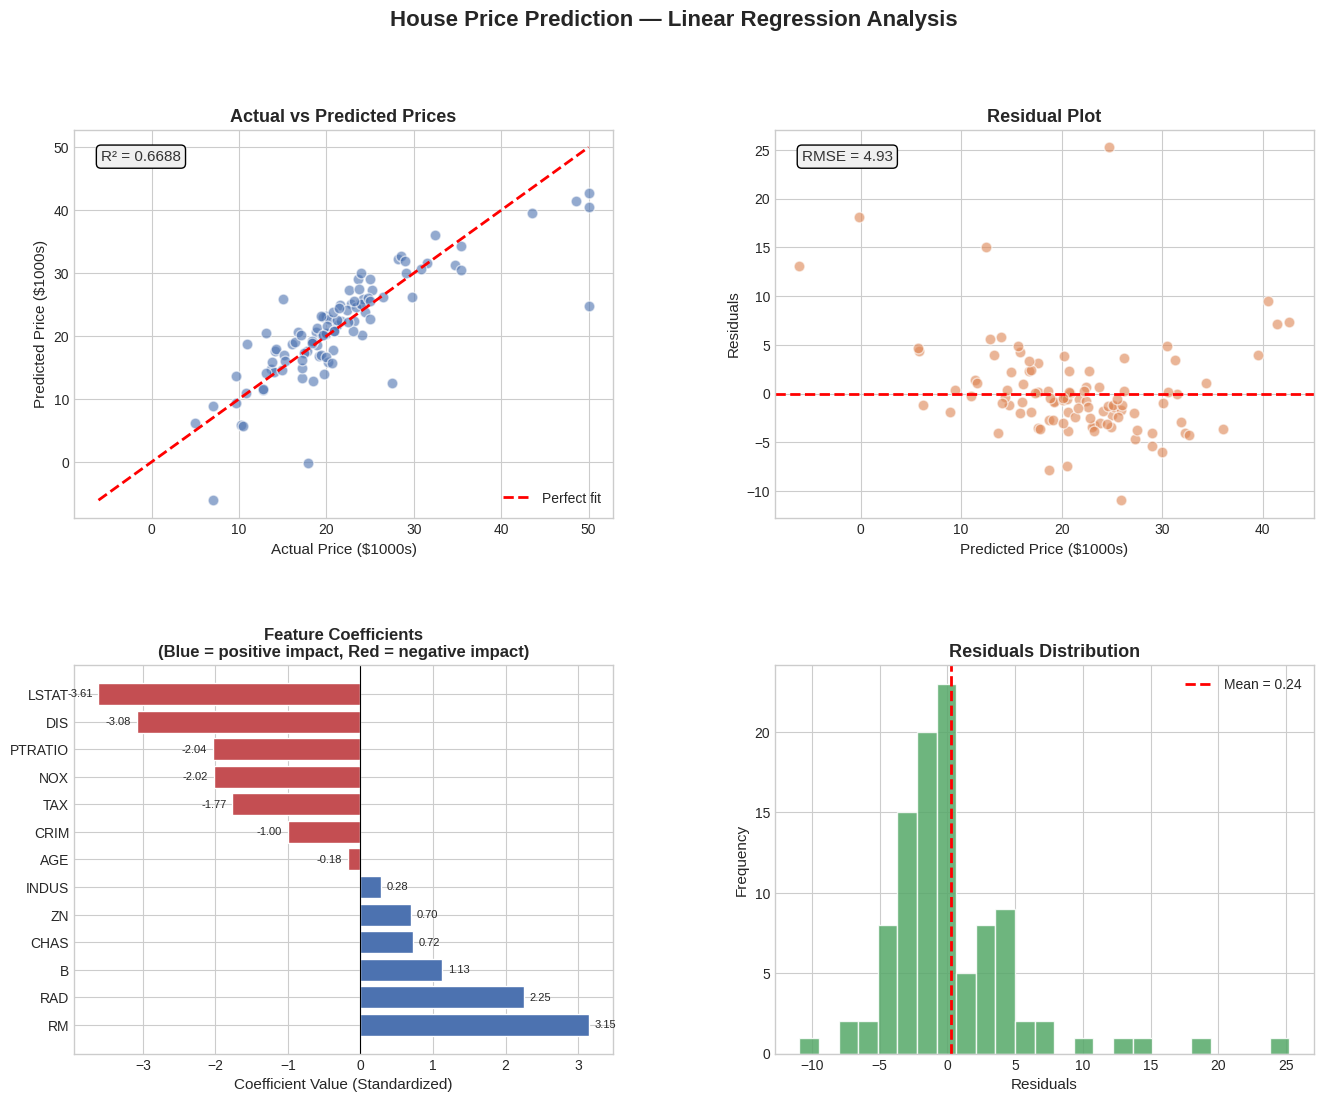

In [9]:
plt.style.use("seaborn-v0_8-whitegrid")
fig = plt.figure(figsize=(16, 12))
fig.suptitle("House Price Prediction — Linear Regression Analysis",
             fontsize=16, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.30)

# ── Panel 1: Actual vs Predicted ──────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test, y_pred_test, alpha=0.6, color="#4C72B0", edgecolors="white", s=60)
lo, hi = min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())
ax1.plot([lo, hi], [lo, hi], "r--", lw=2, label="Perfect fit")
ax1.set_xlabel("Actual Price ($1000s)", fontsize=11)
ax1.set_ylabel("Predicted Price ($1000s)", fontsize=11)
ax1.set_title("Actual vs Predicted Prices", fontsize=13, fontweight="bold")
ax1.legend()
ax1.text(0.05, 0.92, f"R² = {r2_test:.4f}", transform=ax1.transAxes,
         fontsize=11, color="#333", bbox=dict(boxstyle="round,pad=0.3", fc="#f0f0f0"))

# ── Panel 2: Residual Plot ─────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
residuals = y_test - y_pred_test
ax2.scatter(y_pred_test, residuals, alpha=0.6, color="#DD8452", edgecolors="white", s=60)
ax2.axhline(0, color="red", linestyle="--", lw=2)
ax2.set_xlabel("Predicted Price ($1000s)", fontsize=11)
ax2.set_ylabel("Residuals", fontsize=11)
ax2.set_title("Residual Plot", fontsize=13, fontweight="bold")
ax2.text(0.05, 0.92, f"RMSE = {rmse_test:.2f}", transform=ax2.transAxes,
         fontsize=11, color="#333", bbox=dict(boxstyle="round,pad=0.3", fc="#f0f0f0"))

# ── Panel 3: Feature Coefficients ─────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
colors = ["#4C72B0" if c > 0 else "#C44E52" for c in coef_df["Coefficient"]]
bars = ax3.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors, edgecolor="white")
ax3.axvline(0, color="black", linewidth=0.8)
ax3.set_xlabel("Coefficient Value (Standardized)", fontsize=11)
ax3.set_title("Feature Coefficients\n(Blue = positive impact, Red = negative impact)",
              fontsize=12, fontweight="bold")
for bar, val in zip(bars, coef_df["Coefficient"]):
    ax3.text(val + (0.08 if val >= 0 else -0.08), bar.get_y() + bar.get_height() / 2,
             f"{val:.2f}", va="center", ha="left" if val >= 0 else "right", fontsize=8)

# ── Panel 4: Distribution of Residuals ────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(residuals, bins=25, color="#55A868", edgecolor="white", alpha=0.85)
ax4.axvline(residuals.mean(), color="red", linestyle="--", lw=2, label=f"Mean = {residuals.mean():.2f}")
ax4.set_xlabel("Residuals", fontsize=11)
ax4.set_ylabel("Frequency", fontsize=11)
ax4.set_title("Residuals Distribution", fontsize=13, fontweight="bold")
ax4.legend()



## 8. SAMPLE PREDICTIONS

In [10]:
print("\n🏠 Sample Predictions (first 8 test rows):")
sample = pd.DataFrame({
    "Actual ($1000s)":    y_test.values[:8].round(1),
    "Predicted ($1000s)": y_pred_test[:8].round(1),
    "Error":              (y_test.values[:8] - y_pred_test[:8]).round(1),
})
print(sample.to_string(index=False))
print("\n" + "=" * 60)
print("  Summary")
print("=" * 60)
print(f"  ✔ R² on test set : {r2_test:.4f}  ({r2_test*100:.1f}% variance explained)")
print(f"  ✔ RMSE           : ${rmse_test:.2f}k  (avg prediction error)")
print(f"  ✔ Top +ve driver : RM      (more rooms → higher price)")
print(f"  ✔ Top -ve driver : LSTAT   (more low-status pop → lower price)")
print("=" * 60)


🏠 Sample Predictions (first 8 test rows):
 Actual ($1000s)  Predicted ($1000s)  Error
            23.6                29.0   -5.4
            32.4                36.0   -3.6
            13.6                14.8   -1.2
            22.8                25.0   -2.2
            16.1                18.8   -2.7
            20.0                23.3   -3.3
            17.8                17.7    0.1
            14.0                14.3   -0.3

  Summary
  ✔ R² on test set : 0.6688  (66.9% variance explained)
  ✔ RMSE           : $4.93k  (avg prediction error)
  ✔ Top +ve driver : RM      (more rooms → higher price)
  ✔ Top -ve driver : LSTAT   (more low-status pop → lower price)
